## 1. 背景：为什么要有激活函数？

假设神经网络只有一层线性变换：

$$
z = Wx + b
$$

如果输出层还是线性的，那么整个模型本质上仍然只是线性函数：

$$
\hat y = w x + b
$$

这意味着：

- 只能拟合直线
- 无法表达复杂非线性关系

所以我们引入激活函数：

$$
a = \phi(z)
$$

神经网络就变成：

$$
\hat y = W_2 \phi(W_1 x + b_1) + b_2
$$

这里的 $\phi(\cdot)$ 就是激活函数。  
**它决定了模型输出是直线、折线，还是平滑曲线。**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 2. 定义常见激活函数

下面定义几种常见激活函数：

### 2.1 无激活（Identity）
$$
f(x) = x
$$

### 2.2 Sigmoid

$$f(x)=\frac{1}{1+e^{-x}}$$

### 2.3 Tanh
$$f(x)=\tanh(x)$$

### 2.4 ReLU
$$f(x)=\max(0,x)$$

### 2.5 Leaky ReLU
$$
f(x)=
\begin{cases}
x, & x>0 \\
\alpha x, & x \le 0
\end{cases}
$$

In [3]:
def identity(x):
    return x

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

## 3. 先看激活函数本身的形状

- Identity：直线
- Sigmoid：S 形压缩到 $(0,1)$
- Tanh：S 形压缩到 $(-1,1)$
- ReLU：负半轴为 0，正半轴线性
- Leaky ReLU：负半轴保留小斜率

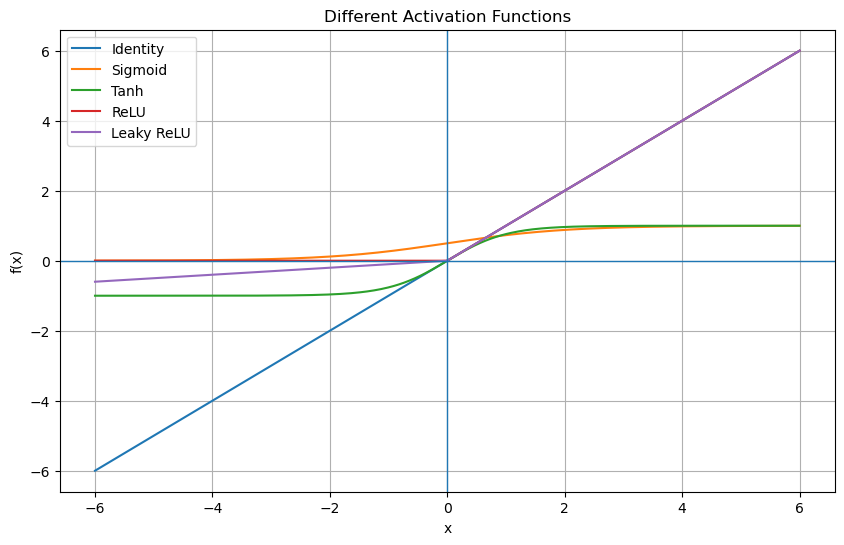

In [6]:
x = np.linspace(-6, 6, 400)

plt.figure(figsize=(10, 6))
plt.plot(x, identity(x), label="Identity")
plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, tanh(x), label="Tanh")
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, leaky_relu(x), label="Leaky ReLU")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("Different Activation Functions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()